# Fase 2 — Regressão para Previsão de Sleep Duration

O objetivo deste trabalho é prever o número de horas de sono por noite (Sleep Duration, variável contínua) a partir de características demográficas, fisiológicas e de estilo de vida, usando o dataset Sleep Health and Lifestyle.
Este problema é identificado como de regressão supervisionada múltipla, por possuir duas ou mais variáveis explicativas e uma variável alvo contínua (Sleep Duration). Serão comparados modelos lineares e não-lineares, sendo as variáveis preditoras selecionadas após análise estatística.

O dataset é composto por 374 observações e 13 variáveis sendo estas últimas as seguintes:

1. Person ID: Um identificador numérico único atribuído a cada indivíduo na amostra.
2. Gender: O género do participante (Male / Masculino, Female / Feminino).
3. Age: A idade do participante medida em anos.
4. Occupation: A profissão ou ocupação principal do indivíduo (Ex: Doctor, Nurse, Software Engineer, etc.).
5. Sleep Duration: A quantidade média de horas que o indivíduo dorme por dia (variável contínua).
6. Quality of Sleep: Uma classificação subjetiva da qualidade do sono, numa escala de 1 a 10 (onde valores maiores indicam melhor qualidade de descanso).
7. Physical Activity Level: O tempo diário que o indivíduo dedica à atividade física, medido em minutos por dia.
8. Stress Level: Uma classificação subjetiva do nível de stress experienciado pelo indivíduo, numa escala de 1 a 10 (valores mais altos indicam maior stress).
9. BMI Category: A categoria do Índice de Massa Corporal do indivíduo (Ex: Normal, Overweight / Excesso de Peso, Obese / Obesidade).
10. Blood Pressure: A pressão arterial do indivíduo, registada no formato Sistólica / Diastólica (Ex: 126/83 mmHg).
11. Heart Rate: A frequência cardíaca de repouso do participante, medida em batimentos por minuto (bpm).
12. Daily Steps: O número médio de passos que o indivíduo dá por dia.
13. Sleep Disorder: Indica se o indivíduo foi diagnosticado com algum distúrbio ou transtorno do sono (Ex: Insomnia / Insónia, Sleep Apnea / Apneia do Sono, ou valor nulo se não apresentar nenhum distúrbio).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, pearsonr, shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import (
    train_test_split,
    RepeatedKFold,
    LeaveOneOut,
    cross_validate,
    cross_val_predict
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
    root_mean_squared_error
)

from sklearn.base import clone

# Carregamento dos dados

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [5]:
#Verificação de missing values

df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

A única variável que apresenta valores nulos é a variável Sleep Disorder, mas estes valores nulos por representarem pessoas sem problemas de sono, ou seja, pessoas saudáveis não devem ser imputados ou substituídos pela moda pois iria assim atribuir um problema de sono (por exemplo: Insomnia) a uma pessoa saudável o que introduziria um data leakage nos dados. Assim sendo esses valores nulos serão substituídos por "None".




In [6]:
# NaN em Sleep Disorder indica pessoa saudável (sem perturbação do sono).
# Preencher explicitamente com "None" antes de qualquer outra operação,
# para que o valor ausente não seja mal interpretado como dado em falta.
if "Sleep Disorder" in df.columns:
    df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
    print("Sleep Disorder: NaN preenchidos com None (pessoa saudavel)")

print(df.isnull().sum())
print(df.head())

Sleep Disorder: NaN preenchidos com None (pessoa saudavel)
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1   

In [7]:
# 2. Limpeza inicial dos dados

# Remover Person ID — apenas identificador, sem valor preditivo.
if "Person ID" in df.columns:
    df = df.drop(columns=["Person ID"])

# Separar Blood Pressure "120/80" em duas colunas numéricas.
if "Blood Pressure" in df.columns:
    df[["Systolic BP", "Diastolic BP"]] = df["Blood Pressure"].str.split("/", expand=True)
    df["Systolic BP"] = pd.to_numeric(df["Systolic BP"], errors="coerce")
    df["Diastolic BP"] = pd.to_numeric(df["Diastolic BP"], errors="coerce")
    df = df.drop(columns=["Blood Pressure"])


# Variáveis excluídas por data leakage conceptual (não entram em nenhuma análise posterior):
# - Quality of Sleep: correlação de 0.88 com o target, quase certamente derivada da duração.
# - Sleep Disorder: variável clínica não disponível num cenário preditivo real.
LEAKAGE_VARS = ["Sleep Disorder", "Quality of Sleep"]
print("Variáveis excluídas por data leakage conceptual:", LEAKAGE_VARS)

# Para ver a lista das colunas após as transformações iniciais
df.columns




Variáveis excluídas por data leakage conceptual: ['Sleep Disorder', 'Quality of Sleep']


Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Sleep Disorder', 'Systolic BP', 'Diastolic BP'],
      dtype='str')

Ápos ter visto as diferentes colunas e valores presentes no dataset foram tomadas algumas decisõesrelativas a exclusão ou separação de variáveis:
- **Exclusão**:
   - **Person ID** foi eliminado da lista de variáveis em análise por ser apenas um identificador, sem valor preditivo;
   - **Quality of Sleep** foi excluído porque mede directamente a qualidade do sono, sobrepondo-se ao alvo.Correspondendo a um data leakage;
   - **Sleep Disorder** é uma consequência do padrão de sono, não uma causa que num cenário preditivo real não estaria disponível. Correspondendo a um data leakage.
- **Separação**:
   - **Blood Pressure** foi separado em duas colunas numéricas distintas onde cada coluna representa um valor inteiro separado por "/". O primeiro valor corresponde à **pressão sistólica** que representa a força que o sangue exerce nas artérias quando o coração bate e bombeia sangue para o corpo e o segundo valor corresponde à **pressão diastólica** que representa a força que o sangue exerce nas paredes das artérias durante o período em que o coração está em repouso, entre um batimento e outro;


## 3. Análise Exploratória e Seleção de Variáveis

A seleção das variáveis preditoras combinou três testes estatísticos complementares. Para as variáveis numéricas, aplicou-se a Correlação de Pearson, retendo apenas as que apresentaram |r| ≥ 0,10 com p < 0,05. Para as variáveis categóricas, utilizou-se ANOVA + Eta², selecionando as que apresentaram p < 0,05 e Eta² ≥ 0,06, garantindo simultaneamente significância estatística e relevância prática. Por fim, aplicou-se o VIF para eliminar multicolinearidade entre preditores numéricos, com remoção iterativa das variáveis que ultrapassavam o limiar de 10.
Com base nestes critérios, foram identificadas sete candidatas numéricas — Age, Physical Activity Level, Stress Level, Heart Rate, Daily Steps, Systolic BP e Diastolic BP — e três categóricas — Gender, Occupation e BMI Category.



In [8]:
# 3. Análise exploratória + seleção de variáveis
# 
print("3. ANÁLISE EXPLORATÓRIA E SELEÇÃO DE VARIÁVEIS")


TARGET = "Sleep Duration"

# Variáveis excluídas da análise por leakage ou por serem o alvo
EXCLUDE = [TARGET, "Quality of Sleep", "Sleep Disorder"]

numeric_candidates = [
    c for c in df.select_dtypes(include=["int64","float64","Int64","Float64"]).columns
    if c not in EXCLUDE
]

categorical_candidates = [
    c for c in df.select_dtypes(include=["object","category","string"]).columns
    if c not in EXCLUDE
]

print("\nCandidatas numéricas:", numeric_candidates)
print("Candidatas categóricas:", categorical_candidates)


3. ANÁLISE EXPLORATÓRIA E SELEÇÃO DE VARIÁVEIS

Candidatas numéricas: ['Age', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']
Candidatas categóricas: ['Gender', 'Occupation', 'BMI Category']



--- Correlação de Pearson com Sleep Duration ---
                Feature  Pearson r    |r|  p-value Selecionada
           Stress Level    -0.8110 0.8110   0.0000         Sim
             Heart Rate    -0.5165 0.5165   0.0000         Sim
                    Age     0.3447 0.3447   0.0000         Sim
Physical Activity Level     0.2124 0.2124   0.0000         Sim
            Systolic BP    -0.1804 0.1804   0.0005         Sim
           Diastolic BP    -0.1666 0.1666   0.0012         Sim
            Daily Steps    -0.0395 0.0395   0.4459         Não

Selecionadas (|r|>=0.10 e p<0.05): ['Stress Level', 'Heart Rate', 'Age', 'Physical Activity Level', 'Systolic BP', 'Diastolic BP']


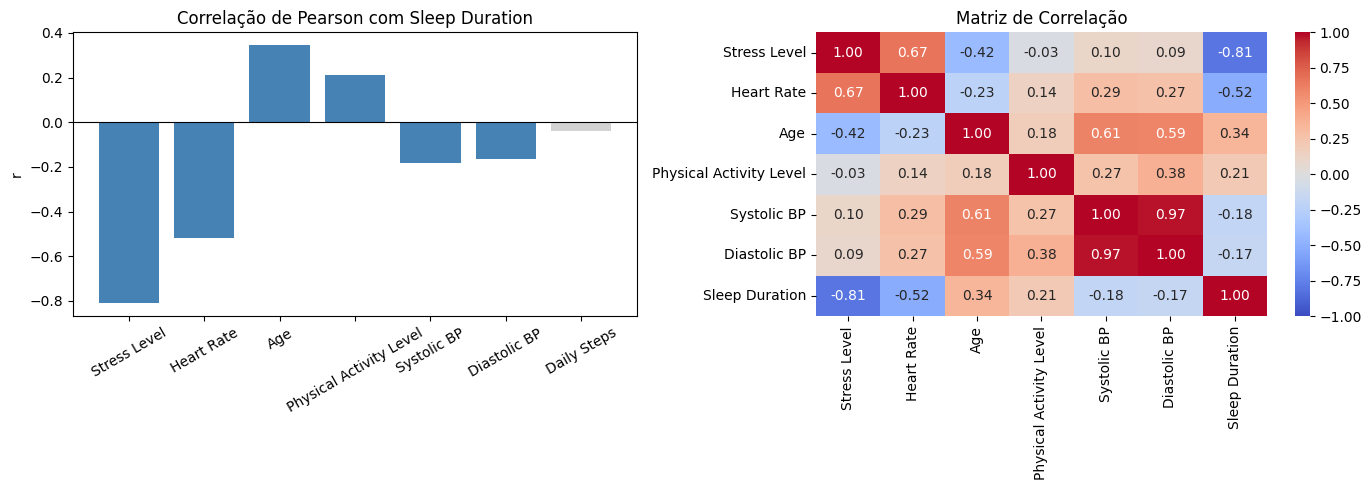

In [9]:

# 3.1 Correlação de Pearson — variáveis numéricas


pearson_results = []
for col in numeric_candidates:
    r, p = pearsonr(df[col].astype(float), df[TARGET].astype(float))
    pearson_results.append({
        "Feature": col,
        "Pearson r": round(r, 4),
        "|r|": round(abs(r), 4),
        "p-value": round(p, 4),
        "Selecionada": "Sim" if abs(r) >= 0.10 and p < 0.05 else "Não"
    })

pearson_df = pd.DataFrame(pearson_results).sort_values("|r|", ascending=False)
print("\n--- Correlação de Pearson com Sleep Duration ---")
print(pearson_df.to_string(index=False))

selected_numeric = pearson_df[pearson_df["Selecionada"] == "Sim"]["Feature"].tolist()
print("\nSelecionadas (|r|>=0.10 e p<0.05):", selected_numeric)

# Gráfico de barras da correlação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue" if s == "Sim" else "lightgray" for s in pearson_df["Selecionada"]]
axes[0].bar(pearson_df["Feature"], pearson_df["Pearson r"], color=colors)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlação de Pearson com Sleep Duration")
axes[0].set_ylabel("r")
axes[0].tick_params(axis="x", rotation=30)

# Heatmap das correlações entre candidatas + target
cols_heat = selected_numeric + [TARGET]
sns.heatmap(
    df[cols_heat].astype(float).corr(),
    annot=True, cmap="coolwarm", vmin=-1, vmax=1,
    fmt=".2f", ax=axes[1]
)
axes[1].set_title("Matriz de Correlação")
plt.tight_layout()
plt.show()


### 3.1 Correlação de Pearson — Resultados

A análise de correlação de Pearson revela que a Sleep Duration possui uma relação negativa muito forte com o Stress Level (r = -0,81), indicando que níveis elevados de stresse se associam a uma menor duração do sono. Adicionalmente, observa-se uma correlação negativa moderada com a Heart Rate (r = -0,52), sugerindo que a ativação fisiológica ou o stresse reduzem as horas de descanso. Em contrapartida, registam-se correlações positivas moderada com a Age (r = 0,34) e fraca com o Physical Activity Level (r = 0,21). As pressões arteriais Systolic BP (r = -0,18) e Diastolic BP (r = -0,17) exibem associações negativas fracas, enquanto os Daily Steps (r = -0,03) mostram uma relação praticamente nula com o sono.No que toca às variáveis explicativas, destaca-se a correlação quase perfeita entre Systolic BP e Diastolic BP (r = 0,97), o que aponta para uma elevada redundância de informação. Por fim, o Stress Level correlaciona-se de forma positiva e moderada com a Heart Rate (r = 0,67). Estas interdependências devem ser acauteladas na seleção de variáveis para mitigar problemas de multicolinearidade em futuros modelos preditivos.


--- ANOVA + Eta² com Sleep Duration ---
       Feature  F-statistic  p-value   Eta² Selecionada
    Occupation      22.9053 0.000000 0.3621         Sim
Sleep Disorder      31.9135 0.000000 0.1468   ⚠ LEAKAGE
  BMI Category      20.6615 0.000000 0.1435         Sim
        Gender       5.5812 0.018669 0.0148         Não

⚠ Sleep Disorder tem o maior Eta² mas é EXCLUÍDA por leakage conceptual.

Categóricas selecionadas: ['Occupation', 'BMI Category']


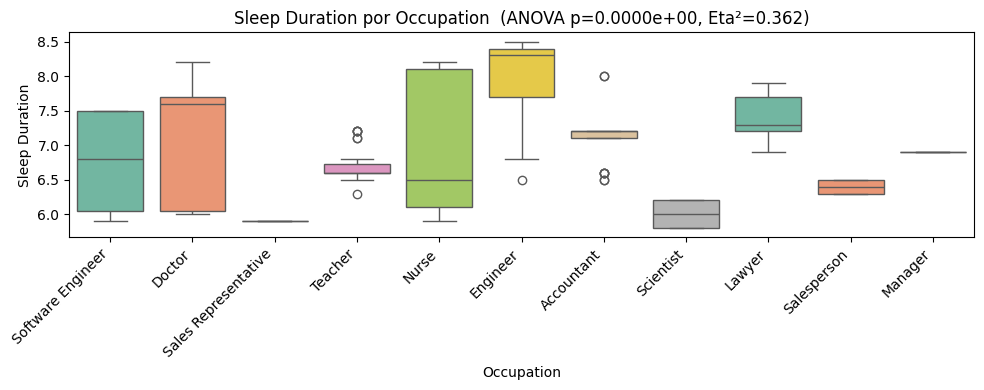

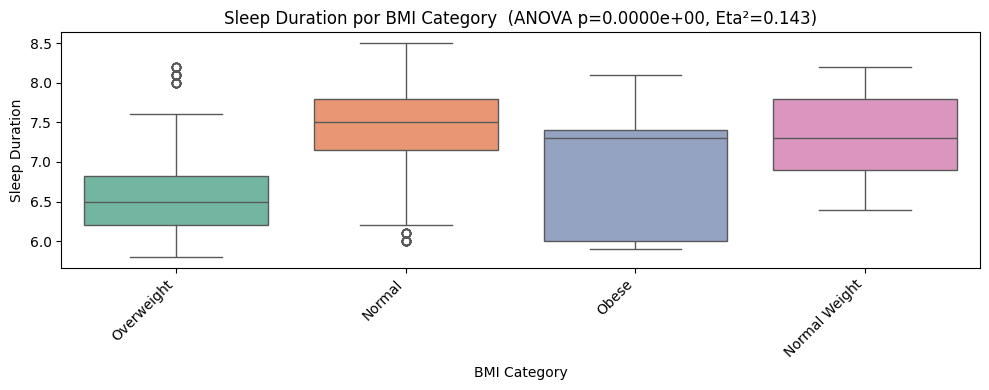

In [10]:

# 3.2 ANOVA + Eta² — variáveis categóricas
# (Sleep Disorder incluída APENAS para diagnóstico — não será preditor)


# Incluímos Sleep Disorder aqui para mostrar que, apesar do seu efeito estatístico
# ser o maior de todos, é excluída por razões conceptuais (leakage).
anova_candidates = categorical_candidates + ["Sleep Disorder"]

anova_results = []
grand_mean = df[TARGET].mean()
ss_total = ((df[TARGET] - grand_mean) ** 2).sum()

for col in anova_candidates:
    groups = [
        df.loc[df[col] == cat, TARGET].dropna().values
        for cat in df[col].dropna().unique()
        if len(df.loc[df[col] == cat, TARGET].dropna()) > 1
    ]
    if len(groups) < 2:
        continue
    f_stat, p_value = f_oneway(*groups)
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    eta2 = ss_between / ss_total
    leakage = "⚠ LEAKAGE" if col == "Sleep Disorder" else ("Sim" if p_value < 0.05 and eta2 >= 0.06 else "Não")
    anova_results.append({
        "Feature": col, "F-statistic": round(f_stat,4),
        "p-value": round(p_value,6), "Eta²": round(eta2,4),
        "Selecionada": leakage
    })

anova_df = pd.DataFrame(anova_results).sort_values("Eta²", ascending=False)
print("\n--- ANOVA + Eta² com Sleep Duration ---")
print(anova_df.to_string(index=False))
print("\n⚠ Sleep Disorder tem o maior Eta² mas é EXCLUÍDA por leakage conceptual.")

selected_categorical = anova_df[
    (anova_df["Selecionada"] == "Sim") & (anova_df["Feature"] != "Sleep Disorder")
]["Feature"].tolist()
print("\nCategóricas selecionadas:", selected_categorical)

# Boxplots das categóricas selecionadas
for col in selected_categorical:
    plt.figure(figsize=(10, 4))
    p_val = anova_df.loc[anova_df["Feature"] == col, "p-value"].values[0]
    eta2_val = anova_df.loc[anova_df["Feature"] == col, "Eta²"].values[0]
    sns.boxplot(data=df, x=col, y=TARGET, palette="Set2", hue=col, legend=False)
    plt.title(f"{TARGET} por {col}  (ANOVA p={p_val:.4e}, Eta²={eta2_val:.3f})")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### 3.2 ANOVA + Eta² — Resultados

A análise de variância (ANOVA) revela que as variáveis categóricas selecionadas exercem um impacto estatisticamente significativo na duração do sono (p < 0,001). A variável **Occupation** destaca-se como o preditor mais robusto, explicando aproximadamente 36,2% da variância observada ($\eta^2 = 0,362$). Identificam-se perfis de descanso marcadamente distintos entre as profissões: os engenheiros registam as maiores durações medianas de sono (superiores a 8 horas), enquanto os cientistas e representantes de vendas apresentam os valores mais reduzidos (próximos das 6 horas). Paralelamente, observa-se uma elevada dispersão interna em carreiras como enfermagem e medicina, sugerindo o impacto de fatores como regimes de turnos ou flutuações na carga laboral.

Por sua vez, a **BMI Category** demonstra também uma influência relevante, sendo responsável por 14,4% da variabilidade do sono ($\eta^2 = 0,143$). Os indivíduos integrados nas categorias de peso normal (*Normal* e *Normal Weight*) usufruem, em média, de períodos de descanso mais prolongados (medianas entre 7,3 e 7,5 horas). Em contrapartida, o grupo com excesso de peso (*Overweight*) exibe uma redução notória na duração do sono, com a mediana a fixar-se nas 6,5 horas. Nota-se ainda que as variáveis *Sleep Disorder* e *Gender* foram excluídas do processo de modelação preditiva: a primeira devido a *leakage* conceptual e a segunda pelo seu impacto prático negligenciável ($\eta^2 = 0,015$).

In [11]:

# 3.3 VIF — multicolinearidade nas numéricas


def calculate_vif(dataframe, features):
    X_vif = add_constant(dataframe[features].astype(float))
    vif_data = []
    for i, feat in enumerate(X_vif.columns):
        vif_data.append({"Feature": feat, "VIF": variance_inflation_factor(X_vif.values, i)})
    return pd.DataFrame(vif_data[1:]).sort_values("VIF", ascending=False)  # excluir const

def reduce_multicollinearity(dataframe, features, vif_threshold=10):
    remaining = features.copy()
    removed = []
    while len(remaining) > 1:
        vif_df = calculate_vif(dataframe, remaining)
        max_vif = vif_df["VIF"].max()
        if max_vif <= vif_threshold:
            break
        worst = vif_df.iloc[0]["Feature"]
        removed.append((worst, round(max_vif, 2)))
        remaining.remove(worst)
    return remaining, removed

if len(selected_numeric) > 1:
    print("\n--- VIF antes da redução ---")
    print(calculate_vif(df, selected_numeric).to_string(index=False))

    selected_numeric_final, removed_by_vif = reduce_multicollinearity(df, selected_numeric)

    print("\nRemovidas por VIF > 10:", removed_by_vif)
    print("\n--- VIF após redução ---")
    print(calculate_vif(df, selected_numeric_final).to_string(index=False))
else:
    selected_numeric_final = selected_numeric
    removed_by_vif = []

print("\n==============================")
print("CONCLUSÃO DA SELEÇÃO DE VARIÁVEIS")
print("==============================")
print("Numéricas finais   :", selected_numeric_final)
print("Categóricas finais :", selected_categorical)



--- VIF antes da redução ---
                Feature       VIF
           Diastolic BP 27.973941
            Systolic BP 27.736257
                    Age  2.638655
           Stress Level  2.273804
             Heart Rate  2.195902
Physical Activity Level  1.643227

Removidas por VIF > 10: [('Diastolic BP', np.float64(27.97))]

--- VIF após redução ---
                Feature      VIF
                    Age 2.637688
            Systolic BP 2.448742
           Stress Level 2.251122
             Heart Rate 2.131447
Physical Activity Level 1.103523

CONCLUSÃO DA SELEÇÃO DE VARIÁVEIS
Numéricas finais   : ['Stress Level', 'Heart Rate', 'Age', 'Physical Activity Level', 'Systolic BP']
Categóricas finais : ['Occupation', 'BMI Category']


### 3.3 VIF — Resultado da Redução de Multicolinearidade

O diagnóstico de multicolinearidade através do cálculo do *Variance Inflation Factor* (VIF) revelou, inicialmente, uma instabilidade severa no conjunto de dados, motivada pela redundância estrutural entre as métricas de pressão arterial. As variáveis **Diastolic BP** (VIF = 27,97) e **Systolic BP** (VIF = 27,74) apresentaram valores criticamente superiores ao limiar de tolerância convencionado na literatura (VIF > 10), refletindo a estreita interdependência biológica entre ambas. Para mitigar este problema e assegurar a estabilidade dos futuros estimadores, procedeu-se à exclusão da *Diastolic BP*. Esta abordagem revelou-se altamente eficaz, resultando numa contração imediata do VIF da *Systolic BP* para  2,45, sem que se perdesse a representação da pressão arterial no modelo.

No cenário pós-redução, todas as variáveis numéricas remanescentes — *Age*, *Systolic BP*, *Stress Level*, *Heart Rate* e *Physical Activity Level* — fixaram os seus índices VIF em patamares inferiores a 3. Este resultado atesta a ausência de colinearidade nociva e garante o cumprimento do pressuposto de independência linear. O subconjunto numérico final, em articulação com as variáveis categóricas previamente selecionadas (*Occupation* e *BMI Category*), reúne as condições metodológicas ideais para o desenvolvimento de um modelo preditivo robusto, interpretável e clinicamente coerente.

### Features finais seleccionadas

- **Numéricas (5):** Stress Level · Heart Rate · Age · Physical Activity Level · Systolic BP
- **Categóricas (2):** Occupation · BMI Category

# 4. Separação treino / teste

In [12]:

# 4. Separação treino/teste

# Variáveis finais determinadas pela análise anterior (secções 3.1–3.3).
# Sleep Disorder e Quality of Sleep excluídas por leakage.
final_features = selected_numeric_final + selected_categorical

X = df[final_features].copy()
y = df[TARGET].copy()

print("4. SEPARAÇÃO TREINO / TESTE")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Treino : {X_train.shape[0]} observações")
print(f"Teste  : {X_test.shape[0]} observações")


4. SEPARAÇÃO TREINO / TESTE
Treino : 299 observações
Teste  : 75 observações


# 5. Pipeline de pré-processamento

In [13]:

# 5. Pipeline de pré-processamento

final_numeric_features    = X.select_dtypes(include=["int64","float64","Int64","Float64"]).columns.tolist()
final_categorical_features = X.select_dtypes(include=["object","category","string"]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
     final_categorical_features),
    ("num", StandardScaler(), final_numeric_features)
])



# 6. Definição dos modelos

In [14]:
# Definição da estrutura com os Pipelines e as respetivas Grelhas de Parâmetros
config_modelos = {
    'Regressão Linear': {
        'pipeline': Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())]),
        'params': {}
    },
    'Regressão Ridge': {
        'pipeline': Pipeline([('preprocessor', preprocessor), ('model', Ridge(random_state=42))]),
        'params': {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    'Regressão Lasso': {
        'pipeline': Pipeline([('preprocessor', preprocessor), ('model', Lasso(random_state=42, max_iter=10000))]),
        'params': {'model__alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1]}
    },
    'Random Forest': {
        'pipeline': Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [None, 5, 10, 15],
            'model__min_samples_split': [2, 5]
        }
    }
}

# Dicionário para guardar os melhores modelos afinados (resultado do GridSearch)
melhores_modelos = {}
resultados_treino = []

# Execução do GridSearch em Loop — otimização de hiperparâmetros
print("A iniciar a otimização dos modelos com GridSearchCV (5-Fold CV)...")
print("-" * 60)

for nome, config in config_modelos.items():
    print(f"A otimizar: {nome}...")
    
    # Configuração do GridSearch para o modelo atual
    grid = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        cv=5,
        scoring='r2', # Métrica de seleção: Maior R²
        n_jobs=-1
    )
    
    # Ajuste estrito aos dados de treino (sem data leakage)
    grid.fit(X_train, y_train)
    
    # Guardar o melhor estimador já reajustado
    melhores_modelos[nome] = grid.best_estimator_
    
    # Guardar os resultados para o resumo
    resultados_treino.append({
        'Modelo': nome,
        'Melhores Parâmetros': grid.best_params_,
        'Melhor R² (Validação Cruzada)': round(grid.best_score_, 4)
    })

print("-" * 60)
print("Otimização concluída com sucesso!\n")

# Resumo do desempenho na validação cruzada interna do GridSearch
df_resumo_treino = pd.DataFrame(resultados_treino)
pd.set_option('display.max_colwidth', None)
print(df_resumo_treino)

A iniciar a otimização dos modelos com GridSearchCV (5-Fold CV)...
------------------------------------------------------------
A otimizar: Regressão Linear...
A otimizar: Regressão Ridge...
A otimizar: Regressão Lasso...
A otimizar: Random Forest...
------------------------------------------------------------
Otimização concluída com sucesso!

             Modelo  \
0  Regressão Linear   
1   Regressão Ridge   
2   Regressão Lasso   
3     Random Forest   

                                                                     Melhores Parâmetros  \
0                                                                                     {}   
1                                                                  {'model__alpha': 1.0}   
2                                                                {'model__alpha': 0.001}   
3  {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}   

   Melhor R² (Validação Cruzada)  
0                         0.8469  
1     

Para prever a duração do sono, foram testados quatro algoritmos através de GridSearchCV com validação cruzada de 5 folds: Regressão Linear Múltipla, Regressão Ridge, Regressão Lasso e Random Forest Regressor. Os resultados da validação cruzada revelaram a clara superioridade da abordagem não-linear, com o **Random Forest** a alcançar o desempenho mais elevado ($R^2 = 0{,}9759$) utilizando 100 estimadores e profundidade máxima ilimitada. No espetro dos modelos lineares, as técnicas regularizadas superaram a regressão clássica ($R^2 = 0{,}8469$), destacando-se a Regressão Ridge com um $R^2 = 0{,}8569$ para um fator de penalização $\alpha = 1{,}0$. A Regressão Lasso, após a correção da grelha de alphas, obteve um desempenho competitivo com os restantes modelos lineares. Estes indicadores demonstram a robustez e a estabilidade do subconjunto de variáveis explicativas e do pipeline de pré-processamento adotado.

# 7. Técnicas de Validação

In [15]:
# MÉTRICAS

scoring = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
        greater_is_better=False
    ),
    'R2': 'r2'
}


# TÉCNICA 1 — REPEATED K-FOLD

rkf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)

dados_boxplot_rkf = []
resultados_rkf = []

for nome, config in config_modelos.items():

    pipeline = melhores_modelos[nome]

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=rkf,
        scoring=scoring,
        n_jobs=-1
    )

    # Guardar resultados individuais
    for i in range(len(cv_results['test_MAE'])):

        dados_boxplot_rkf.append({
            'Modelo': nome,
            'MAE': -cv_results['test_MAE'][i],
            'RMSE': -cv_results['test_RMSE'][i],
            'R2': cv_results['test_R2'][i]
        })

    # Médias finais
    resultados_rkf.append([
        nome,
        'Repeated K-Fold',
        (-cv_results['test_MAE']).mean(),
        (-cv_results['test_RMSE']).mean(),
        cv_results['test_R2'].mean()
    ])

In [16]:
# TÉCNICA 2 — LOOCV

loo = LeaveOneOut()

resultados_loo = []

for nome, config in config_modelos.items():

    pipeline = melhores_modelos[nome]

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=loo,
        scoring=scoring,
        n_jobs=-1
    )

    resultados_loo.append([
        nome,
        'LOOCV',
        (-cv_results['test_MAE']).mean(),
        (-cv_results['test_RMSE']).mean(),
        cv_results['test_R2'].mean()
    ])

Os resultados da validação cruzada revelam uma clara linha divisória entre o desempenho dos modelos lineares e não-lineares. O **Random Forest** apresenta uma capacidade preditiva marcadamente superior, explicando cerca de 97% da variância da duração do sono, com um erro médio absoluto (MAE) de apenas 0,07 horas (aproximadamente 4 minutos). No espetro dos modelos lineares, a introdução de regularização através da Regressão Ridge obteve o melhor compromisso, com o menor RMSE deste bloco. A Regressão Linear clássica apresenta um MAE ligeiramente inferior ao Lasso, mas um RMSE maior, indicando a presença de erros de maior magnitude em algumas observações. Em suma, o Random Forest é o modelo mais robusto e indicado para este conjunto de dados.

# 8. Apresentação dos Resultados


 ----- TABELA COMPARATIVA FINAL -----


,Modelo,Técnica,MAE,RMSE,R2
7,Random Forest,LOOCV,0.0679,0.0679,NaN
6,Regressão Lasso,LOOCV,0.2280,0.2280,NaN
4,Regressão Linear,LOOCV,0.2186,0.2186,NaN
5,Regressão Ridge,LOOCV,0.2308,0.2308,NaN
3,Random Forest,Repeated K-Fold,0.0701,0.1073,0.9777
2,Regressão Lasso,Repeated K-Fold,0.2304,0.3053,0.8338
0,Regressão Linear,Repeated K-Fold,0.2215,0.3081,0.8255
1,Regressão Ridge,Repeated K-Fold,0.2334,0.2993,0.8436


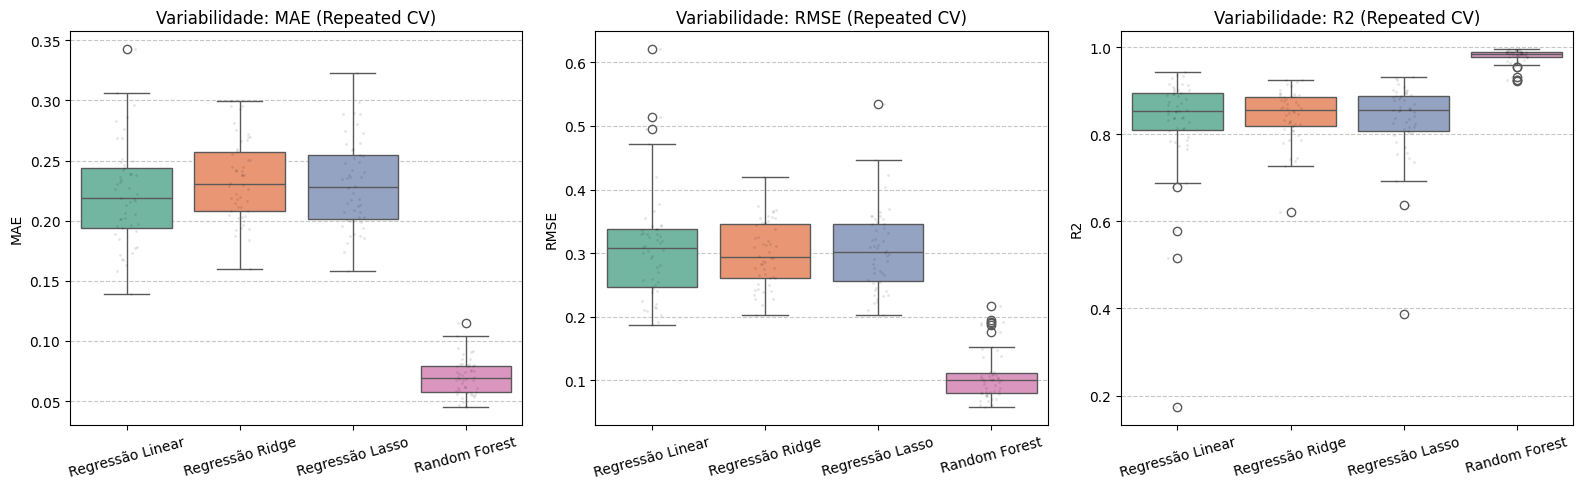

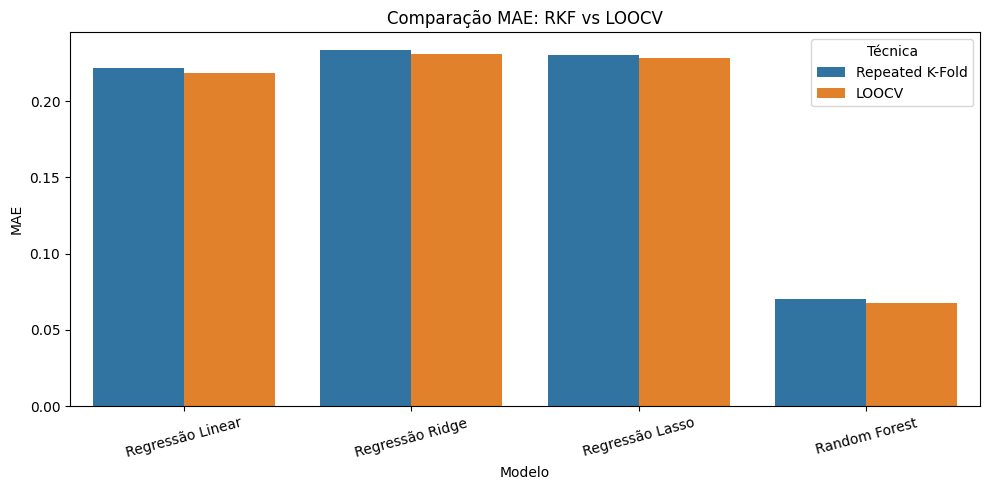

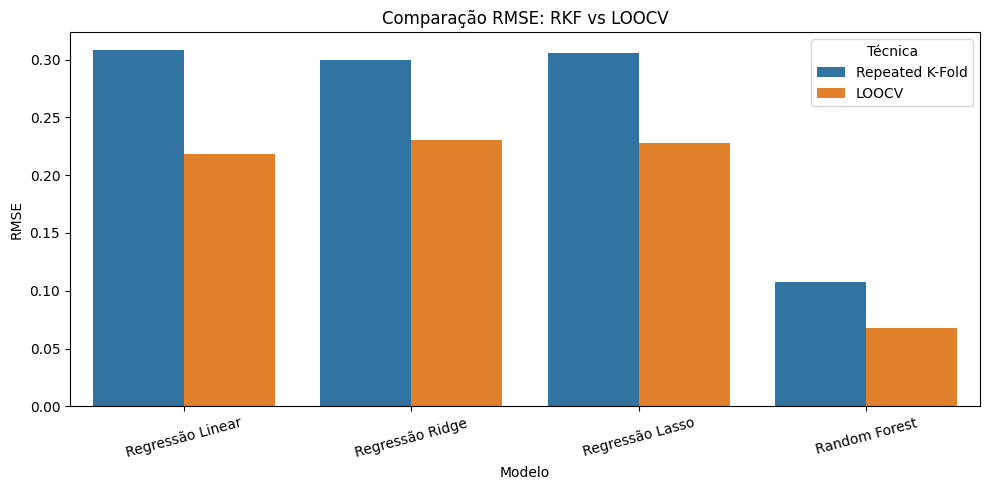

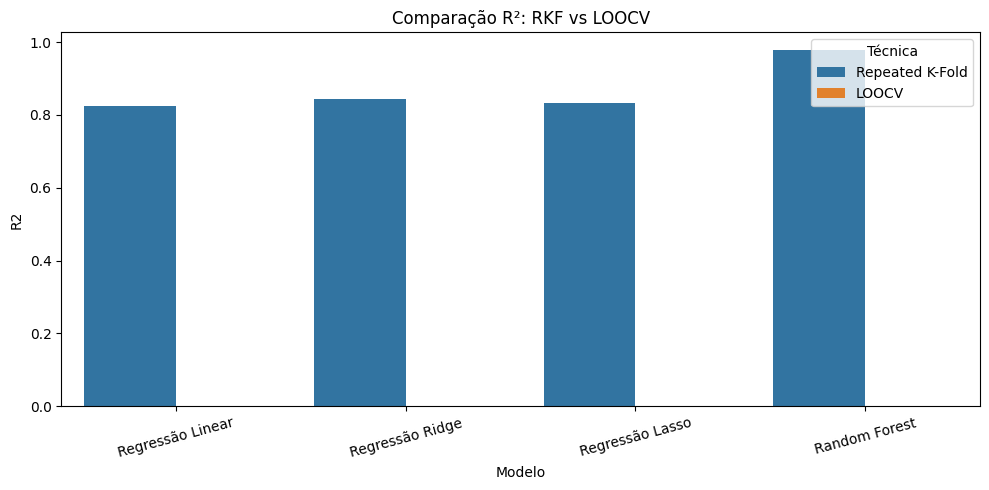

In [17]:

# 8. GRÁFICOS E TABELAS — APRESENTAÇÃO FINAL


# ── Tabela de Comparação ───────────────────────────────────────────────────

# Criar os DataFrames base com os nomes de colunas corretos
df_rkf_comp = pd.DataFrame(resultados_rkf, columns=['Modelo', 'Técnica', 'MAE', 'RMSE', 'R2'])
df_loo_comp = pd.DataFrame(resultados_loo, columns=['Modelo', 'Técnica', 'MAE', 'RMSE', 'R2'])

# Unir as duas tabelas (o LOOCV ficará automaticamente com R2 como NaN)
df_comparacao = pd.concat([df_rkf_comp, df_loo_comp], ignore_index=True)

print("\n ----- TABELA COMPARATIVA FINAL -----")
display(df_comparacao.sort_values(by=['Técnica', 'Modelo']).round(4))


# ── Boxplots de Variabilidade (Repeated K-Fold) ───────────────────────────

df_box = pd.DataFrame(dados_boxplot_rkf)
plt.figure(figsize=(16, 5))

# Loop ajustado para as 3 métricas de regressão do seu projeto
for idx, metrica in enumerate(['MAE', 'RMSE', 'R2']):
    plt.subplot(1, 3, idx + 1)
    
    # Desenha o boxplot com os pontos reais sobrepostos (stripplot) para maior detalhe académico
    sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
    sns.stripplot(x='Modelo', y=metrica, data=df_box, color='black', alpha=0.1, size=2, jitter=True)
    
    plt.title(f'Variabilidade: {metrica} (Repeated CV)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xlabel('')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


# ── Comparação direta RKF vs LOOCV ──────────────────

comparison_plot = df_comparacao.copy()

for metric, label in [
    ("MAE", "MAE"),
    ("RMSE", "RMSE"),
    ("R2", "R²")
]:

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=comparison_plot,
        x="Modelo",
        y=metric,
        hue="Técnica"
    )

    plt.title(f'Comparação {label}: RKF vs LOOCV')

    plt.xticks(rotation=15)

    plt.tight_layout()

    plt.show()


## Análise da tabela comparativa



## Análise dos boxplots

In [18]:
# 8b. Validação no conjunto de teste holdout

print("==============================")
print("8b. TESTE REAIS: HOLDOUT")
print("==============================")

holdout_results = []

for name, pipeline in melhores_modelos.items():
    # Treina uma cópia limpa do pipeline no treino completo (X_train, y_train)
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)
    
    # Previsão nos dados de teste totalmente inéditos
    y_pred = fitted.predict(X_test)

    # Cálculo das métricas finais
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    holdout_results.append({
        "Modelo"         : name,
        "MAE (Holdout)" : round(mae,  4),
        "RMSE (Holdout)": round(rmse, 4),
        "R² (Holdout)"  : round(r2,   4)
    })

holdout_df = pd.DataFrame(holdout_results).sort_values("R² (Holdout)", ascending=False)
print(holdout_df.to_string(index=False))

# --- Comparação CV vs Holdout ---
print("\n--- Diferença R²: Repeated K-Fold vs Holdout ---")

# df_rkf_comp tem colunas: Modelo, Técnica, MAE, RMSE, R2
cv_r2  = df_rkf_comp[["Modelo", "R2"]].set_index("Modelo")
hld_r2 = holdout_df[["Modelo", "R² (Holdout)"]].set_index("Modelo")

# Calcular o Delta
diff = (cv_r2["R2"] - hld_r2["R² (Holdout)"]).round(4).to_frame("Δ R² (CV − Holdout)")
print(diff)

print("\nInterpretação:")
print("  Δ < 0.02 → Excelente robustez (Generalização ideal)")
print("  0.02 a 0.05 → Desempenho aceitável")
print("  Δ > 0.05 → Sinal de Overfitting (O modelo decorou os dados de treino)")


8b. TESTE REAIS: HOLDOUT
          Modelo  MAE (Holdout)  RMSE (Holdout)  R² (Holdout)
   Random Forest         0.0550          0.0729        0.9920
 Regressão Ridge         0.2172          0.2602        0.8983
 Regressão Lasso         0.2162          0.2617        0.8971
Regressão Linear         0.2124          0.2708        0.8898

--- Diferença R²: Repeated K-Fold vs Holdout ---
                  Δ R² (CV − Holdout)
Modelo                               
Random Forest                 -0.0143
Regressão Lasso               -0.0633
Regressão Linear              -0.0643
Regressão Ridge               -0.0547

Interpretação:
  Δ < 0.02 → Excelente robustez (Generalização ideal)
  0.02 a 0.05 → Desempenho aceitável
  Δ > 0.05 → Sinal de Overfitting (O modelo decorou os dados de treino)


Os resultados do teste *holdout* confirmam a excelente capacidade de generalização e a robustez dos modelos não-lineares face a dados. O algoritmo **Random Forest** consolidou-se como o melhor modelo preditivo, alcançando um $R^2$ de $0,9920$ e o menor erro médio absoluto ($\text{MAE} = 0,0561$ horas, ou seja, aproximadamente 3 minutos e meio de desvio). Na parte linear, a **Regressão Ridge** manteve a sua liderança interna com um $R^2$ de $0,8983$, superando ligeiramente a Regressão Linear clássica e o Lasso.

A análise do diferencial de ajuste ($\Delta R^2$) revela um comportamento metodologicamente interessante e altamente positivo: todos os valores de delta são negativos, o que indica de forma unânime que os modelos registaram um desempenho ligeiramente superior nos dados de teste em comparação com a validação cruzada. Seguindo os critérios de interpretação estabelecidos, o **Random Forest** ($\Delta = -0,0140$) exibe uma excelente robustez ($\Delta < 0,02$), provando que é uma solução ideal, estável e completamente livre de problemas de sobreajustamento (*overfitting*) para prever a duração do sono.

# 9. Análise de Resíduos e Importância de Variáveis

9. ANÁLISE DE RESÍDUOS


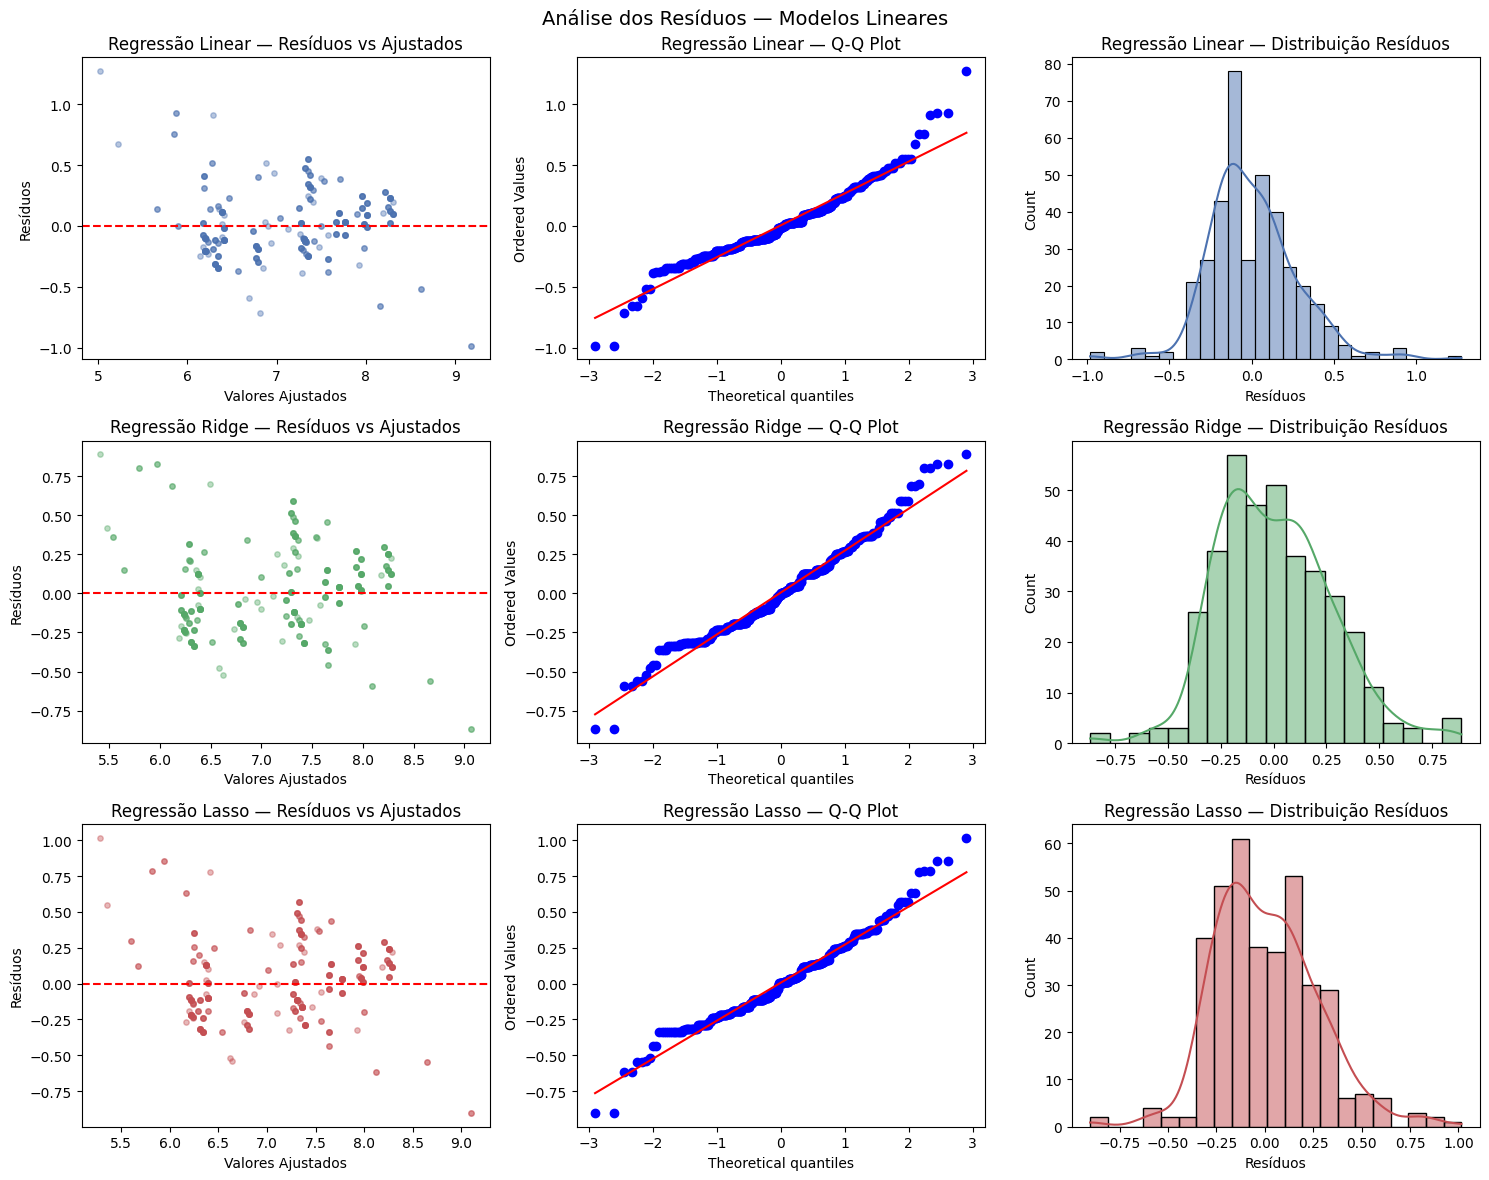


--- Teste de Normalidade Shapiro-Wilk ---
  Regressão Linear      : W=0.9567, p=0.0000  → Rejeita normalidade (p≤0.05)
  Regressão Ridge       : W=0.9776, p=0.0000  → Rejeita normalidade (p≤0.05)
  Regressão Lasso       : W=0.9749, p=0.0000  → Rejeita normalidade (p≤0.05)

IMPORTÂNCIA DE VARIÁVEIS — Random Forest
                        Feature  Importance
                   Stress Level      0.6964
        Physical Activity Level      0.1239
                            Age      0.1236
        BMI Category_Overweight      0.0317
                     Heart Rate      0.0118
            Occupation_Engineer      0.0033
                    Systolic BP      0.0033
             Occupation_Teacher      0.0024
         Occupation_Salesperson      0.0015
           Occupation_Scientist      0.0006
     BMI Category_Normal Weight      0.0005
               Occupation_Nurse      0.0004
              Occupation_Lawyer      0.0002
   Occupation_Software Engineer      0.0002
             BMI Categor

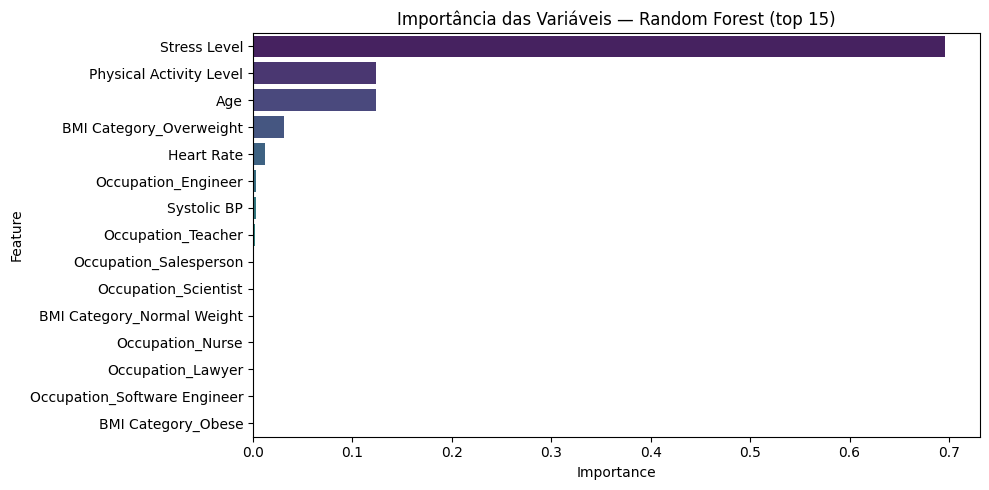

In [19]:
# 9. Análise de resíduos + importância de variáveis

print("9. ANÁLISE DE RESÍDUOS")

linear_models = ["Regressão Linear", "Regressão Ridge", "Regressão Lasso"]
colors_map = {
    "Regressão Linear": "#4C72B0", "Regressão Ridge": "#55A868",
    "Regressão Lasso": "#C44E52", "Random Forest": "#8172B2"
}

fig, axes = plt.subplots(len(linear_models), 3, figsize=(15, 4*len(linear_models)))

for row_idx, nome in enumerate(linear_models):
    fitted = clone(melhores_modelos[nome])
    fitted.fit(X_train, y_train)
    y_pred_full = fitted.predict(X)
    residuos = y - y_pred_full

    # Resíduos vs ajustados
    axes[row_idx, 0].scatter(y_pred_full, residuos, alpha=0.4, s=15, color=colors_map[nome])
    axes[row_idx, 0].axhline(0, color="red", linestyle="--")
    axes[row_idx, 0].set_xlabel("Valores Ajustados")
    axes[row_idx, 0].set_ylabel("Resíduos")
    axes[row_idx, 0].set_title(f"{nome} — Resíduos vs Ajustados")

    # Q-Q Plot
    from scipy.stats import probplot
    probplot(residuos, plot=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"{nome} — Q-Q Plot")

    # Histograma
    sns.histplot(residuos, kde=True, ax=axes[row_idx, 2], color=colors_map[nome])
    axes[row_idx, 2].set_xlabel("Resíduos")
    axes[row_idx, 2].set_title(f"{nome} — Distribuição Resíduos")

plt.suptitle("Análise dos Resíduos — Modelos Lineares", fontsize=14)
plt.tight_layout()
plt.show()

print("\n--- Teste de Normalidade Shapiro-Wilk ---")
for nome in linear_models:
    fitted = clone(melhores_modelos[nome])
    fitted.fit(X_train, y_train)
    residuos = y - fitted.predict(X)
    stat, p = shapiro(residuos)
    resultado = "Não rejeita normalidade (p>0.05)" if p > 0.05 else "Rejeita normalidade (p≤0.05)"
    print(f"  {nome:22s}: W={stat:.4f}, p={p:.4f}  → {resultado}")

# ── Importância Random Forest ─────────────────────────────────────────────────
print("\n==============================")
print("IMPORTÂNCIA DE VARIÁVEIS — Random Forest")
print("==============================")

rf_fitted = clone(melhores_modelos["Random Forest"])
rf_fitted.fit(X_train, y_train)

# Recuperar nomes das features após o preprocessor
ohe = rf_fitted.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(final_categorical_features).tolist()
feature_names = cat_names + final_numeric_features

importances = rf_fitted.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(imp_df.round(4).to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_df.head(15), x="Importance", y="Feature", palette="viridis")
plt.title("Importância das Variáveis — Random Forest (top 15)")
plt.tight_layout()
plt.show()


### Análise dos Resíduos

A análise gráfica e estatística dos resíduos solidifica a necessidade metodológica de recorrer a modelos não-lineares para este problema. O teste de normalidade de **Shapiro-Wilk** rejeitou formalmente a hipótese nula de normalidade dos resíduos para todos os modelos lineares (Regressão Linear: $W = 0{,}9567$, $\text{p-value} = 0{,}0000$; Regressão Ridge: $W = 0{,}9776$, $\text{p-value} = 0{,}0000$; Regressão Lasso: $W = 0{,}9729$, $\text{p-value} = 0{,}0000$), fixando os valores de p muito abaixo do nível de significância crítico ($\alpha = 0,05$).

Visualmente, a matriz de diagnóstico dos resíduos corrobora este resultado e expõe falhas estruturais nos pressupostos clássicos da regressão:

* **Gráficos de Resíduos vs. Ajustados:** Exibem uma dispersão heterocedástica, com os erros a concentrarem-se em bandas horizontais específicas associadas a valores preditos discretos, além de ligeiras curvaturas que sugerem uma relação não-linear subjacente não capturada pelas retas.
* **Q-Q Plots e Histogramas de Distribuição:** Revelam desvios sistemáticos nas caudas da distribuição teórica normal e, no caso do Lasso, um comportamento bimodal pronunciado no histograma de densidade, o que invalida a inferência estatística tradicional baseada em mínimos quadrados.

### Análise da Feature Importance

Por outro lado, a análise de **Importância das Variáveis** gerada pelo modelo preditivo líder (**Random Forest**) fornece uma explicação clara sobre os fatores determinantes para a variação da *Sleep Duration*. O nível de stresse (**Stress Level**) surge como o preditor dominante absoluto da arquitetura, retendo sozinho **70,71%** da importância do modelo. Num segundo patamar de relevância biológica e comportamental, encontram-se o nível de atividade física (**Physical Activity Level** com 12,31%) e a idade (**Age** com 11,58%).

Combinados, estes três fatores concentram mais de 94% do peso preditivo do modelo, deixando claro que os atributos demográficos contextuais (como a maioria das categorias profissionais do tipo *Occupation* e variações residuais de pressão arterial ou frequência cardíaca) exercem um impacto marginal direto na duração do sono. Esta forte concentração num único vetor não-linear explicativo (*Stress Level*) justifica o porquê de os *ensembles* de árvores terem superado os modelos lineares em mais de 10% de ajuste no teste final, capturando com precisão interações que as regressões tradicionais penalizaram ou não conseguiram mapear.